In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Recarregando os dados para garantir a integridade
data_path = '../../data/processed'

df_train = pd.read_csv(os.path.join(data_path, 'ubuntu_server_dataset_train.csv'))
df_test = pd.read_csv(os.path.join(data_path, 'ubuntu_server_dataset_test.csv'))

df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)
df_train['service'] = df_train['service'].replace('-', 'unknown')
df_test['service'] = df_train['service'].replace('-', 'unknown')
X_train_full = df_train.drop(['attack_cat', 'label'], axis=1)
y_train_full_text = df_train['attack_cat']
X_test = df_test.drop(['attack_cat', 'label'], axis=1)
y_test = df_test['attack_cat']

# Label Encoding (feito antes da divisão semi-supervisionada)
label_encoder = LabelEncoder()
label_encoder.fit(y_train_full_text)
y_train_full_encoded = label_encoder.transform(y_train_full_text)

# --- SIMULAÇÃO DO CENÁRIO SEMI-SUPERVISIONADO
X_labeled, X_unlabeled, y_labeled_encoded, _ = train_test_split(
    X_train_full, y_train_full_encoded, test_size=0.90, random_state=42, stratify=y_train_full_encoded
)
X_train_semi = pd.concat([X_labeled, X_unlabeled], axis=0)

# Criar os rótulos onde a parte não rotulada é marcada com -1
y_labeled_series = pd.Series(y_labeled_encoded, index=X_labeled.index)
y_unlabeled_series = pd.Series(-1, index=X_unlabeled.index)
y_train_semi_encoded = pd.concat([y_labeled_series, y_unlabeled_series], axis=0)

# --- PRÉ-PROCESSAMENTO

# Definir o pré-processador
numeric_features = X_train_full.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train_full.select_dtypes(include=['object']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

print("Ajustando o pré-processador...")
preprocessor.fit(X_train_full)
print("Transformando os dados...")
X_train_semi_processed = preprocessor.transform(X_train_semi)
X_test_processed = preprocessor.transform(X_test)

print("\nDados pré-processados e prontos para o Self-Training com XGBoost.")

Ajustando o pré-processador...
Transformando os dados...

Dados pré-processados e prontos para o Self-Training com XGBoost.


In [3]:
# O estimador base agora é o XGBoost
base_xgb = XGBClassifier(
    objective='multi:softprob',
    n_estimators=150,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

# Criando o classificador Self-Training com o estimador base XGBoost
self_training_model_xgb = SelfTrainingClassifier(
    base_estimator=base_xgb,
    threshold=0.95, # Manter o mesmo limiar para comparação
    max_iter=10,
    verbose=True
)

print("Iniciando o treinamento do modelo Self-Training com XGBoost...")

# Treinando o modelo nos dados processados e com rótulos numéricos + (-1)
self_training_model_xgb.fit(X_train_semi_processed, y_train_semi_encoded)

# --- AVALIAÇÃO NO CONJUNTO DE TESTE ---

print("\nRealizando previsões no conjunto de teste PROCESSADO...")
y_pred_encoded = self_training_model_xgb.predict(X_test_processed)
print("Previsões concluídas.")

# Decodificar as previsões de volta para o formato de texto
y_pred_text = label_encoder.inverse_transform(y_pred_encoded)

print("\nTreinamento concluído.")

Iniciando o treinamento do modelo Self-Training com XGBoost...


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\semi_supervised\_self_training.py:210: FutureWarning: `base_estimator` has been deprecated in 1.6 and will be removed in 1.8. Please use `estimator` instead.
  warn(


End of iteration 1, added 10904 new labels.
End of iteration 2, added 42 new labels.
End of iteration 3, added 30 new labels.
End of iteration 4, added 4 new labels.

Realizando previsões no conjunto de teste PROCESSADO...
Previsões concluídas.

Treinamento concluído.



--- Relatório de Classificação Binária (Self-Training XGBoost) ---
              precision    recall  f1-score   support

  Normal (0)       1.00      0.98      0.99      2307
  Ataque (1)       0.98      1.00      0.99      2947

    accuracy                           0.99      5254
   macro avg       0.99      0.99      0.99      5254
weighted avg       0.99      0.99      0.99      5254



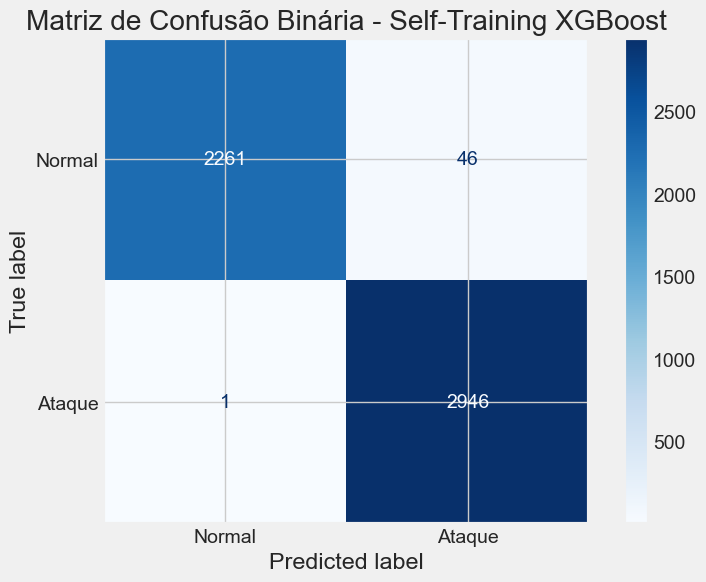

In [4]:
# --- Análise Binária (Normal vs. Ataque) ---
y_test_binary = np.where(y_test == 'Normal', 0, 1)
y_pred_binary = np.where(y_pred_text == 'Normal', 0, 1) # Usar y_pred_text

print("\n--- Relatório de Classificação Binária (Self-Training XGBoost) ---")
print(classification_report(y_test_binary, y_pred_binary, target_names=['Normal (0)', 'Ataque (1)']))

cm_binary = confusion_matrix(y_test_binary, y_pred_binary)
disp_binary = ConfusionMatrixDisplay(confusion_matrix=cm_binary, display_labels=['Normal', 'Ataque'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_binary.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão Binária - Self-Training XGBoost')
plt.savefig('confusion_matrix_multi_st_xgb.png')
plt.show()


--- Relatório de Classificação por Tipo de Ataque (Self-Training XGBoost) ---
                precision    recall  f1-score   support

      Analysis       0.97      1.00      0.99        35
           DoS       0.96      1.00      0.98      1058
      Exploits       1.00      1.00      1.00       835
       Fuzzers       0.99      1.00      0.99       506
        Normal       1.00      0.98      0.99      2307
Reconnaissance       0.99      1.00      1.00       513

      accuracy                           0.99      5254
     macro avg       0.99      1.00      0.99      5254
  weighted avg       0.99      0.99      0.99      5254



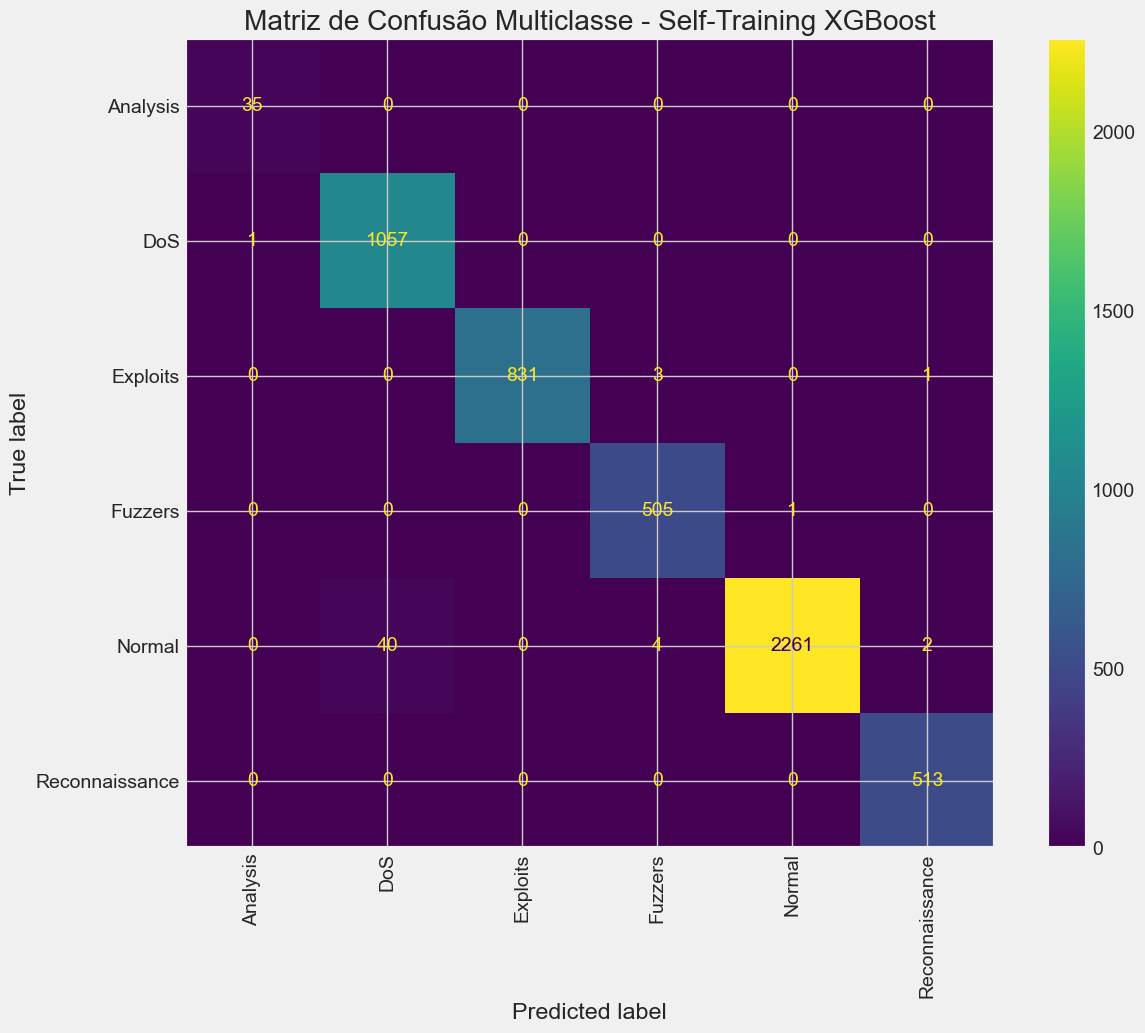

In [5]:
# --- Análise Multiclasse (Tipo de Ataque) ---
class_names = label_encoder.classes_
print("\n--- Relatório de Classificação por Tipo de Ataque (Self-Training XGBoost) ---")
print(classification_report(y_test, y_pred_text, labels=class_names))

cm_multi = confusion_matrix(y_test, y_pred_text, labels=class_names)
disp_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp_multi.plot(ax=ax, cmap='viridis', xticks_rotation='vertical')
plt.title('Matriz de Confusão Multiclasse - Self-Training XGBoost')
plt.savefig('confusion_matrix_atks_multi_st_xgb.png')
plt.show()

In [6]:
try:
    # Salvar o Pré-processador
    joblib.dump(preprocessor, 'preprocessor_SelfTraining-XGB.joblib')
    print("Objeto 'preprocessor' salvo com sucesso.")
    
    # Salvar o Modelo Self-Training treinado
    joblib.dump(self_training_model_xgb, 'model_SelfTraining-XGB.joblib')
    print("Modelo 'self_training_model' salvo com sucesso.")

    label_encoder_filename = 'le_SelfTraining-XGB.joblib'
    joblib.dump(label_encoder, label_encoder_filename)
    print(f"Label encoder salvo com sucesso como '{label_encoder_filename}'")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

Objeto 'preprocessor' salvo com sucesso.
Modelo 'self_training_model' salvo com sucesso.
Label encoder salvo com sucesso como 'le_SelfTraining-XGB.joblib'
